In [3]:
import pandas as pd
ruta = "/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/PUNTOS/Base de datos/MenM__Geohazards.csv"

puntos = pd.read_csv(ruta, encoding='latin1',
    sep=';',
    decimal=','
)
puntos.info()
puntos.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   type     511 non-null    object 
 1   date     511 non-null    object 
 2   lng      511 non-null    float64
 3   lat      511 non-null    float64
 4   Barrio   371 non-null    object 
dtypes: float64(2), object(3)
memory usage: 20.1+ KB


,type,date,lng,lat,Barrio
0,Landslide,31/12/2017,-75.606000,6.276000,NaN
1,Landslide,28/04/2018,-75.604805,6.243001,NaN
2,Landslide,21/05/2018,-75.604077,6.235881,NaN
3,Landslide,29/10/1975,-75.604077,6.235881,NaN
4,Landslide,14/07/1999,-75.603016,6.213929,NaN


In [5]:
from pointpats import centrography
mprom_cent = centrography.mean_center(puntos[['lng', 'lat']])
med_center = centrography.euclidean_median(puntos[['lng', 'lat']])

In [13]:
!pip install contextily
import seaborn as sbn
import matplotlib.pyplot as plt
import contextily as ctx

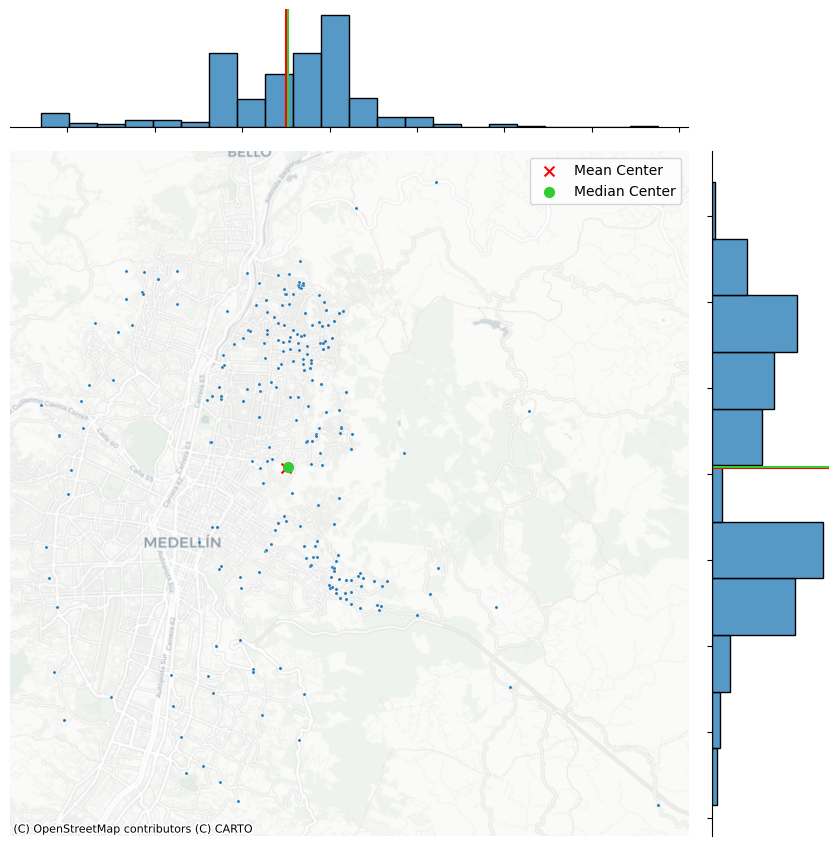

In [83]:
joint_axes = sbn.jointplot(x='lng', y='lat',data=puntos,s=5,height=9)

joint_axes.ax_joint.scatter(*mprom_cent, color='red', marker='x', s=50, label='Mean Center')
joint_axes.ax_marg_x.axvline(mprom_cent[0], color='red')
joint_axes.ax_marg_y.axhline(mprom_cent[1], color='red')

joint_axes.ax_joint.scatter(*med_center, color='limegreen', marker='o', s=50, label='Median Center')
joint_axes.ax_marg_x.axvline(med_center[0], color='limegreen')
joint_axes.ax_marg_y.axhline(med_center[1], color='limegreen')

joint_axes.ax_joint.legend()

ctx.add_basemap(joint_axes.ax_joint,source=ctx.providers.CartoDB.Positron, crs="EPSG:4326")

joint_axes.ax_joint.set_axis_off()

plt.show()

In [15]:
centrography.std_distance(puntos[['lng','lat']])

np.float64(0.035070048251237204)

In [16]:
major, minor, rotation = centrography.ellipse(puntos[['lng','lat']])

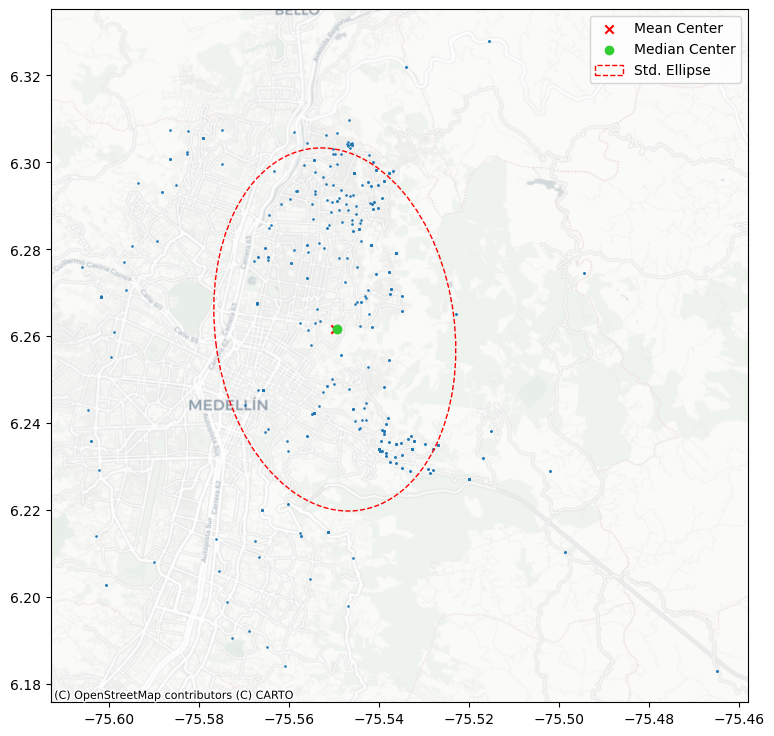

In [77]:
from matplotlib.patches import Ellipse
import numpy as np

f, ax = plt.subplots(1, figsize=(9, 9))

ax.scatter(puntos['lng'], puntos['lat'], s=0.75)
ax.scatter(*mprom_cent, color='red', marker='x', label='Mean Center')
ax.scatter(*med_center, color='limegreen', marker='o', label='Median Center')


ellipse = Ellipse(xy=mprom_cent,
                  width=major*2,
                  height=minor*2,
                  angle = np.rad2deg(rotation),
                  facecolor='none',
                  edgecolor='red', linestyle='--',
                  label='Std. Ellipse')
ax.add_patch(ellipse)

ax.legend()

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:4326",
    zorder=0)
plt.show()

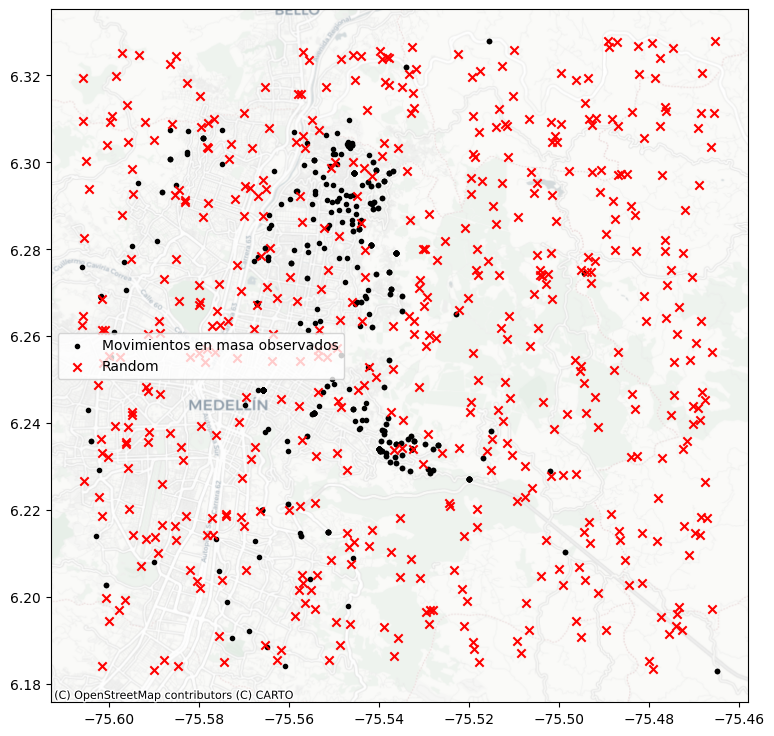

In [76]:
from pointpats import distance_statistics, QStatistic, random, PointPattern
coordenadas = puntos[['lng','lat']].values
random_pattern = random.poisson(coordenadas, size=len(coordenadas))

f,ax = plt.subplots(1, figsize=(9, 9))
plt.scatter(*coordenadas.T, color='k', marker='.', label='Movimientos en masa observados')
plt.scatter(*random_pattern.T, color='r', marker='x', label='Random')
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:4326",
    zorder=0)
ax.legend(ncol=1, loc='center left')
plt.show()

In [30]:
import libpysal
alpha_shape, alpha, circs = libpysal.cg.alpha_shape_auto(coordenadas, return_circles=True)

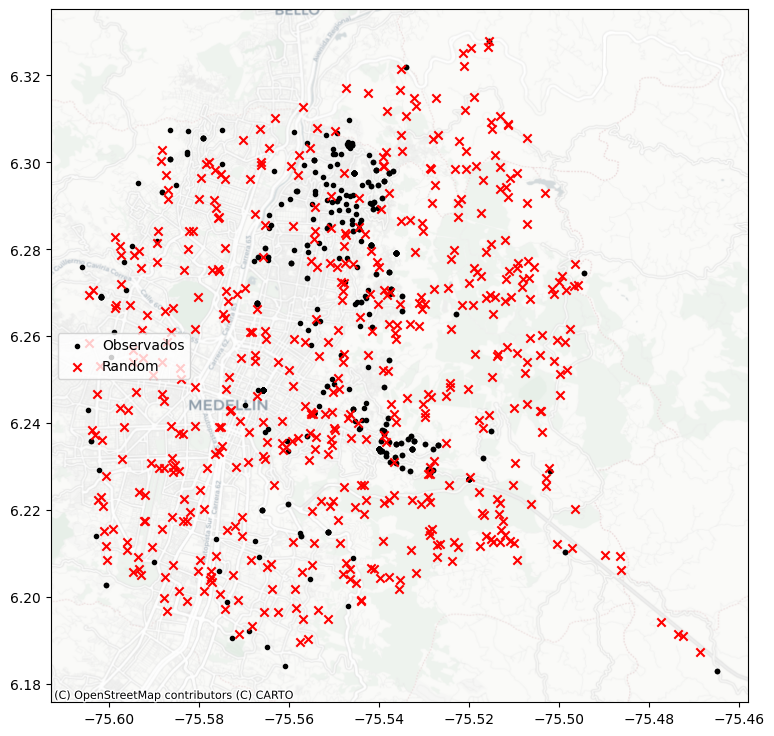

In [75]:
random_pattern_ashape = random.poisson(alpha_shape, size=len(coordenadas))

f,ax = plt.subplots(1, figsize=(9, 9))
plt.scatter(*coordenadas.T, color='k', marker='.', label='Observados')
plt.scatter(*random_pattern_ashape.T, color='r', marker='x', label='Random')
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:4326",
    zorder=0)
ax.legend(ncol=1, loc='center left')
plt.show()

#Estadística por cuadrantes

np.float64(1.883651938602613e-62)

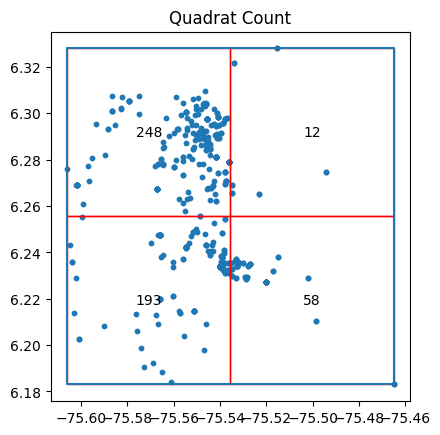

In [33]:
qstat = QStatistic(coordenadas, nx = 2, ny = 2)
qstat.plot()
qstat.chi2_pvalue

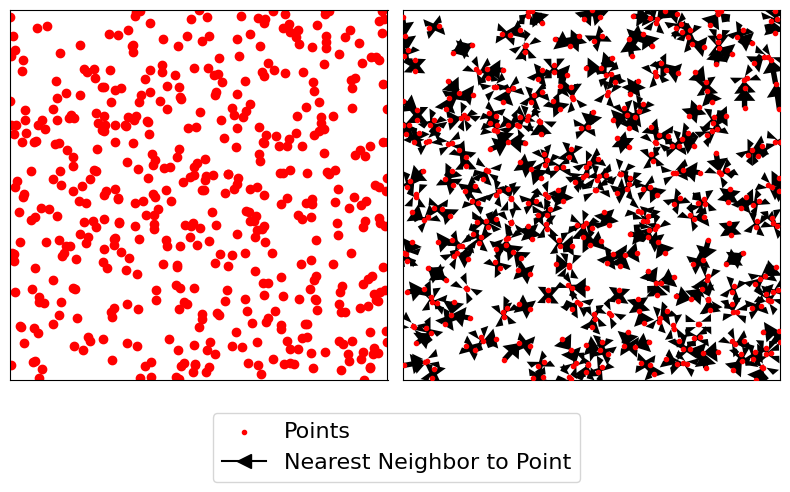

In [56]:
# this code should be hidden in the book, and only the plot visible!
f,ax = plt.subplots(1,2,figsize=(8,4), sharex=True, sharey=True)
ax[0].scatter(*random_pattern.T, color='red')
ax[1].scatter(*random_pattern.T, color='red',
              zorder=100, marker='.', label='Points')
nn_ixs, nn_ds = PointPattern(random_pattern).knn(1)
first = True
for coord, nn_ix, nn_d in zip(random_pattern, nn_ixs, nn_ds):
    dx, dy = random_pattern[nn_ix].squeeze() - coord
    arrow = ax[1].arrow(*coord,
        dx,
        dy,
        length_includes_head=True,
        overhang=0,
        head_length=0.005,
        head_width=0.008,
        width=0.002,
        linewidth=0,
        facecolor='black',
        head_starts_at_zero=False)
    if first:
        plt.plot((1e100, 1e101), (0,1), color='k',
                 marker='<', markersize=10,
                 label='Nearest Neighbor to Point')
    first = False

xmin, ymin = random_pattern.min(axis=0)
xmax, ymax = random_pattern.max(axis=0)

ax[0].axis([xmin, xmax, ymin, ymax])
ax[1].axis([xmin, xmax, ymin, ymax])
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])
ax[0].set_xticks([])
ax[0].set_yticks([])
f.tight_layout()
ax[1].legend(bbox_to_anchor = (.5,-.06), fontsize=16)
plt.show()

In [57]:
g_test = distance_statistics.g_test(coordenadas, support=40, keep_simulations=True)

In [60]:
print(g_test.support.shape)
print(g_test.simulations.shape)
print(g_test.statistic.shape)
print(g_test.support)


(40,)
(9999, 40)
(40,)
[0.         0.00030729 0.00061457 0.00092186 0.00122914 0.00153643
 0.00184371 0.002151   0.00245828 0.00276557 0.00307285 0.00338014
 0.00368742 0.00399471 0.00430199 0.00460928 0.00491656 0.00522385
 0.00553114 0.00583842 0.00614571 0.00645299 0.00676028 0.00706756
 0.00737485 0.00768213 0.00798942 0.0082967  0.00860399 0.00891127
 0.00921856 0.00952584 0.00983313 0.01014041 0.0104477  0.01075498
 0.01106227 0.01136956 0.01167684 0.01198413]


/tmp/ipykernel_3537/2454837544.py:29: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


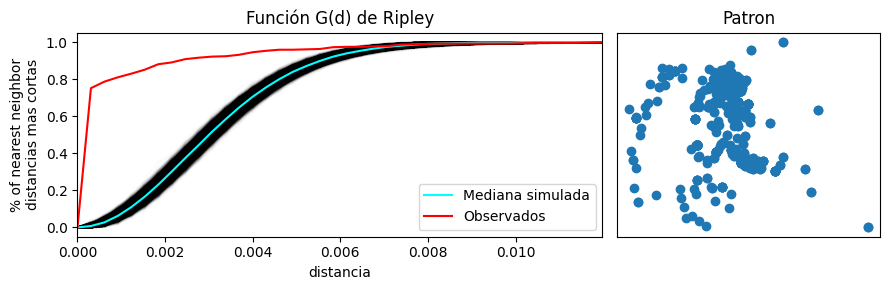

In [63]:
f,ax = plt.subplots(1,2,figsize=(9,3),gridspec_kw=dict(width_ratios=(6,3)))
# plot all the simulations with very fine lines
ax[0].plot(g_test.support, g_test.simulations.T, color='k', alpha=.01)
# and show the average of simulations
ax[0].plot(g_test.support, np.median(g_test.simulations, axis=0), color='cyan',label='Mediana simulada')


# and the observed pattern's G function
ax[0].plot(g_test.support, g_test.statistic, label = 'Observados', color='red')

# clean up labels and axes
ax[0].set_xlabel('distancia')
ax[0].set_ylabel('% of nearest neighbor\ndistancias mas cortas')
ax[0].legend()
ax[0].set_xlim(
    g_test.support.min(),
    g_test.support.max())
ax[0].set_title('Función G(d) de Ripley')

# plot the pattern itself on the next frame
ax[1].scatter(*coordenadas.T)

# and clean up labels and axes there, too
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].set_title('Patron')
f.tight_layout()
plt.show()

In [89]:
from sklearn.cluster import DBSCAN
# Define DBSCAN
clusterer = DBSCAN(eps=0.001,
    min_samples=5)
# Fit to our data
clusterer.fit(puntos[["lng", "lat"]])

DBSCAN(eps=0.001)

In [86]:
print(lbls.value_counts())

0    511
Name: count, dtype: int64


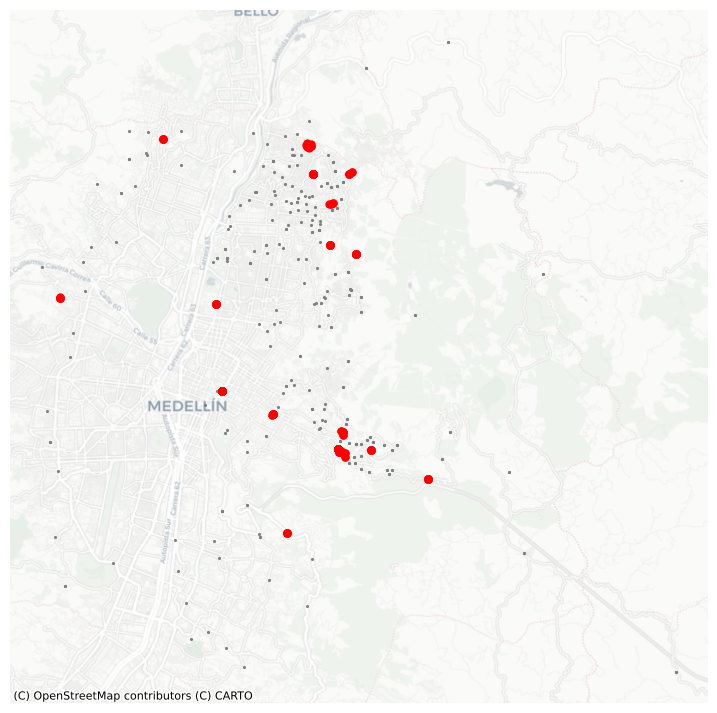

In [90]:
lbls = pd.Series(clusterer.labels_, index=puntos.index)
# Setup figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Subset points that are not part of any cluster (noise)
ruido = puntos.loc[lbls==-1, ['lng', 'lat']]
# Plot noise in grey
ax.scatter(ruido['lng'], ruido['lat'], c='grey', s=5, linewidth=0)
# Plot all points that are not noise in red
# NOTE how this is done through some fancy indexing, where
#      we take the index of all points (tw) and substract from
#      it the index of those that are noise
ax.scatter(puntos.loc[puntos.index.difference(ruido.index), 'lng'], \
           puntos.loc[puntos.index.difference(ruido.index), 'lat'], \
          c='red', linewidth=0)
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    crs="EPSG:4326",
    zorder=0)
# Remove axes
ax.set_axis_off()
# Display the figure
plt.show()